In [2]:
!pip -q install --no-cache-dir pandas numpy scipy scikit-learn matplotlib seaborn
!pip -q install --no-cache-dir torch torch-geometric
!pip -q install --no-cache-dir tensorflow==2.19.1 tf-keras

In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, HeteroData
from torch_geometric.nn import GCNConv, GATConv, HANConv

import tensorflow as tf

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.0.2
Pandas: 2.2.2
PyTorch: 2.10.0+cu128
TensorFlow: 2.19.1


In [4]:
DATA_DIR = Path.cwd()
SEED = 42
SAMPLE_SIZE = 3000
TRAIN_SIZE = 0.60
VAL_SIZE = 0.20
TEST_SIZE = 0.20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def load_elliptic_common(data_dir: Path, sample_size: int = 3000, seed: int = 42):
    features_df = pd.read_csv("elliptic_txs_features.csv", header=None)
    edges_df = pd.read_csv("elliptic_txs_edgelist.csv")
    classes_df = pd.read_csv("elliptic_txs_classes.csv")

    # feature matrix
    tx_ids_all = features_df[0].astype(int).values
    X_all = features_df.iloc[:, 2:].astype(float).values
    X_all[np.isinf(X_all)] = np.nan
    X_all = np.nan_to_num(X_all, nan=0.0)

    scaler = StandardScaler()
    X_all = scaler.fit_transform(X_all)
    X_all = np.nan_to_num(X_all, nan=0.0).astype(np.float32)

    # labels
    classes_df = classes_df.copy()
    classes_df["class"] = classes_df["class"].astype(str)
    classes_df = classes_df[classes_df["class"].isin(["1", "2"])].copy()
    classes_df["class"] = classes_df["class"].map({"1": 1, "2": 0}).astype(int)

    label_map = dict(zip(classes_df["txId"].astype(int), classes_df["class"].astype(int)))
    y_all = np.array([label_map.get(tx, -1) for tx in tx_ids_all], dtype=np.int64)

    labeled_mask = y_all != -1
    tx_ids = tx_ids_all[labeled_mask]
    X = X_all[labeled_mask]
    y = y_all[labeled_mask]

    if sample_size < len(y):
        sample_idx, _ = train_test_split(
            np.arange(len(y)),
            train_size=sample_size,
            stratify=y,
            random_state=seed,
        )
        sample_idx = np.array(sample_idx, dtype=np.int64)
    else:
        sample_idx = np.arange(len(y), dtype=np.int64)

    tx_ids = tx_ids[sample_idx]
    X = X[sample_idx]
    y = y[sample_idx]

    txid_to_idx = {int(tx): i for i, tx in enumerate(tx_ids)}

    edges_df = edges_df.copy()
    edges_df["txId1"] = edges_df["txId1"].astype(int)
    edges_df["txId2"] = edges_df["txId2"].astype(int)

    src_idx = edges_df["txId1"].map(txid_to_idx)
    dst_idx = edges_df["txId2"].map(txid_to_idx)
    valid = (~src_idx.isna()) & (~dst_idx.isna())

    edge_pairs = np.vstack([
        src_idx[valid].astype(int).values,
        dst_idx[valid].astype(int).values,
    ])

    rev_pairs = edge_pairs[::-1]
    edge_pairs = np.concatenate([edge_pairs, rev_pairs], axis=1)

    edge_index = torch.tensor(edge_pairs, dtype=torch.long)

    n = len(y)
    adj = sp.coo_matrix(
        (np.ones(edge_index.shape[1], dtype=np.float32),
         (edge_index[0].numpy(), edge_index[1].numpy())),
        shape=(n, n),
        dtype=np.float32,
    ).tocsr()
    adj.setdiag(0)
    adj.eliminate_zeros()

    return {
        "X": X.astype(np.float32),
        "y": y.astype(np.int64),
        "tx_ids": tx_ids,
        "edge_index": edge_index,
        "adj": adj,
        "dataframes": (features_df, edges_df, classes_df),
    }

base = load_elliptic_common(DATA_DIR, sample_size=SAMPLE_SIZE, seed=SEED)
X = base["X"]
y = base["y"]
edge_index = base["edge_index"]
adj = base["adj"]

print("Common sample shape:", X.shape, y.shape)
print("Edge index shape:", edge_index.shape)
print("Adj shape:", adj.shape)
print("Class balance:", np.bincount(y))

Device: cuda
Common sample shape: (3000, 165) (3000,)
Edge index shape: torch.Size([2, 324])
Adj shape: (3000, 3000)
Class balance: [2707  293]


In [5]:
def make_splits(y_arr, seed=42):
    idx = np.arange(len(y_arr))
    train_idx, temp_idx = train_test_split(
        idx, train_size=TRAIN_SIZE, stratify=y_arr, random_state=seed
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=y_arr[temp_idx], random_state=seed
    )
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idx, val_idx, test_idx = make_splits(y, SEED)
print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))

def build_masks(n, train_idx, val_idx, test_idx):
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

train_mask, val_mask, test_mask = build_masks(len(y), train_idx, val_idx, test_idx)

def tune_threshold(y_true, probs, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    best_t = 0.5
    best_f1 = -1.0
    for t in grid:
        pred = (probs >= t).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = float(t)
    return best_t, best_f1

def compute_metrics(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, probs),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, probs)
    except Exception:
        out["roc_auc"] = np.nan
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    out["tn"], out["fp"], out["fn"], out["tp"] = cm.ravel()
    out["threshold"] = threshold
    return out

def probs_from_logits(logits):
    return F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

def plot_confusion(cm, title):
    plt.figure(figsize=(4.8, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred licit", "Pred illicit"],
        yticklabels=["True licit", "True illicit"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_model_comparison(results_df):
    metrics = ["f1", "precision", "recall", "pr_auc", "roc_auc", "accuracy"]
    plot_df = results_df.set_index("model")[metrics]
    ax = plot_df.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Model comparison on the same Elliptic subgraph")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.legend(loc="best", ncol=3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Split sizes: 1800 600 600


In [6]:
x_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.long)

pyg_data = Data(x=x_torch, edge_index=edge_index, y=y_torch)

print(pyg_data)
print("num_nodes:", pyg_data.num_nodes)
print("num_edges:", pyg_data.num_edges)

Data(x=[3000, 165], edge_index=[2, 324], y=[3000])
num_nodes: 3000
num_edges: 324


/tmp/ipykernel_4717/859420378.py:69: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f"epoch {epoch+1:03d} | loss={float(loss):.4f} "


epoch 020 | loss=0.6452 val_pr_auc=0.1039 val_f1@0.5=0.1878
Early stopping.
HAN metrics: {'accuracy': 0.19166666666666668, 'precision': 0.10536044362292052, 'recall': 0.9827586206896551, 'f1': 0.19031719532554256, 'pr_auc': np.float64(0.16354008883626628), 'roc_auc': np.float64(0.5747391525639395), 'tn': np.int64(58), 'fp': np.int64(484), 'fn': np.int64(1), 'tp': np.int64(57), 'threshold': 0.48999999999999994, 'best_val_pr_auc': 0.10393441602500594, 'best_val_f1': 0.18780889621087316}
              precision    recall  f1-score   support

           0     0.9831    0.1070    0.1930       542
           1     0.1054    0.9828    0.1903        58

    accuracy                         0.1917       600
   macro avg     0.5442    0.5449    0.1917       600
weighted avg     0.8982    0.1917    0.1928       600



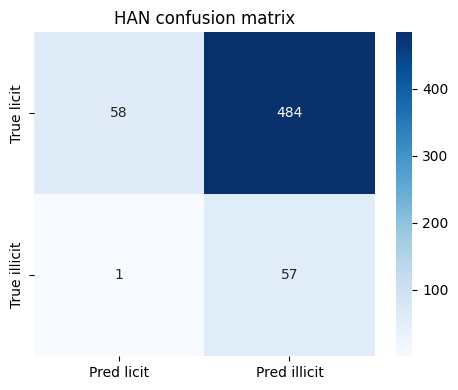

In [8]:
hetero = HeteroData()
hetero["tx"].x = x_torch.clone()
hetero["tx"].y = y_torch.clone()
hetero["tx"].train_mask = train_mask.clone()
hetero["tx"].val_mask = val_mask.clone()
hetero["tx"].test_mask = test_mask.clone()
hetero["tx", "interact", "tx"].edge_index = edge_index.clone()

class HANModel(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, out_channels=2, heads=4, dropout=0.5, metadata=None):
        super().__init__()
        self.han = HANConv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=heads,
            metadata=metadata,
        )
        self.lin = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.han(x_dict, edge_index_dict)
        x = F.relu(x_dict["tx"])
        x = self.dropout(x)
        x = self.lin(x)
        return x

def train_han(model, hetero_data, lr=0.005, epochs=120, patience=15):
    device = next(model.parameters()).device
    hetero_data = hetero_data.to(device)

    y_train = hetero_data["tx"].y[hetero_data["tx"].train_mask].detach().cpu().numpy()
    class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = deepcopy(model.state_dict())
    best_val_score = -1.0
    best_val_probs = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(hetero_data.x_dict, hetero_data.edge_index_dict)
        loss = F.cross_entropy(out[hetero_data["tx"].train_mask], hetero_data["tx"].y[hetero_data["tx"].train_mask], weight=class_weights)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out_val = model(hetero_data.x_dict, hetero_data.edge_index_dict)[hetero_data["tx"].val_mask]
            val_probs = probs_from_logits(out_val)
            y_val = hetero_data["tx"].y[hetero_data["tx"].val_mask].detach().cpu().numpy()
            val_pr_auc = average_precision_score(y_val, val_probs)

        if val_pr_auc > best_val_score:
            best_val_score = val_pr_auc
            best_state = deepcopy(model.state_dict())
            best_val_probs = val_probs.copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 20 == 0:
            y_val_pred = (val_probs >= 0.5).astype(int)
            print(
                f"epoch {epoch+1:03d} | loss={float(loss):.4f} "
                f"val_pr_auc={val_pr_auc:.4f} val_f1@0.5={f1_score(y_val, y_val_pred, zero_division=0):.4f}"
            )

        if wait >= patience:
            print("Early stopping.")
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(hetero_data.x_dict, hetero_data.edge_index_dict)[hetero_data["tx"].test_mask]
        test_probs = probs_from_logits(test_logits)
        y_test = hetero_data["tx"].y[hetero_data["tx"].test_mask].detach().cpu().numpy()

    best_thr, best_val_f1 = tune_threshold(
        hetero_data["tx"].y[hetero_data["tx"].val_mask].detach().cpu().numpy(),
        best_val_probs
    )
    metrics = compute_metrics(y_test, test_probs, threshold=best_thr)
    metrics["best_val_pr_auc"] = float(best_val_score)
    metrics["best_val_f1"] = float(best_val_f1)
    return model, metrics, y_test, test_probs, best_thr

han = HANModel(
    in_channels=x_torch.shape[1],
    hidden_channels=128,
    out_channels=2,
    heads=4,
    dropout=0.5,
    metadata=hetero.metadata(),
).to(device)

han, han_metrics, y_test_han, p_test_han, thr_han = train_han(
    han, hetero, lr=0.005, epochs=120, patience=15
)

print("HAN metrics:", han_metrics)
print(classification_report(y_test_han, (p_test_han >= thr_han).astype(int), digits=4, zero_division=0))
plot_confusion(np.array([[han_metrics["tn"], han_metrics["fp"]], [han_metrics["fn"], han_metrics["tp"]]]), "HAN confusion matrix")